In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/FINAL MINI PROJECT/labeled_data.csv")

In [ ]:
df['label'] = df['class'].apply(lambda x: 1 if x in [0,1] else 0)

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    return text

df['tweet'] = df['tweet'].apply(clean_text)

In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['tweet'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 111.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

In [ ]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
test_dataset = Dataset(test_encodings, test_labels)

In [ ]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=2
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/FINAL MINI PROJECT/roberta_results",

    num_train_epochs=2,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    save_strategy="steps",        # 🔥 save by steps (NOT epoch)
    save_steps=300,               # 🔥 checkpoint every ~300 steps

    save_total_limit=2,           # 🔥 only keep last 2 checkpoints (saves space)

    logging_steps=100,

    logging_dir="/content/drive/MyDrive/FINAL MINI PROJECT/roberta_logs",

    report_to="none"              # avoid extra logging issues
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

In [ ]:
trainer.train()

# 🔥 auto save after training finishes
trainer.save_model("/content/drive/MyDrive/FINAL MINI PROJECT/roberta_model")
tokenizer.save_pretrained("/content/drive/MyDrive/FINAL MINI PROJECT/roberta_model")

print("✅ Model saved successfully!")

Step,Training Loss
100,0.492990
200,0.448237
300,0.516013
400,0.443541
500,0.492972
600,0.469812
700,0.432787
800,0.490528
900,0.490960
1000,0.447834


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully!


In [ ]:
preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(axis=1)

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(test_labels, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, y_pred, average='binary')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9312083921726851
Precision: 0.9567528388499638
Recall: 0.9606986899563319
F1 Score: 0.9587217043941412


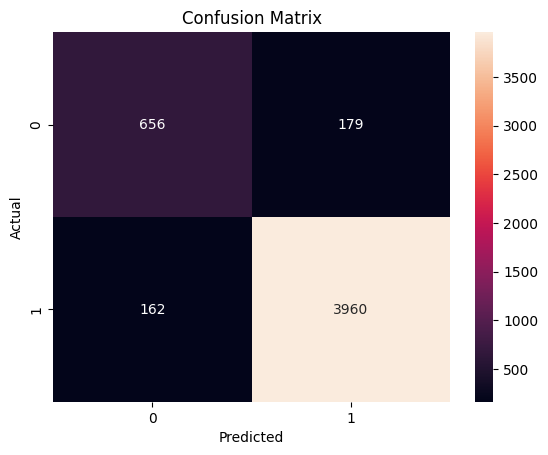

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

results.to_csv("/content/drive/MyDrive/FINAL MINI PROJECT/roberta_metrics.csv", index=False)

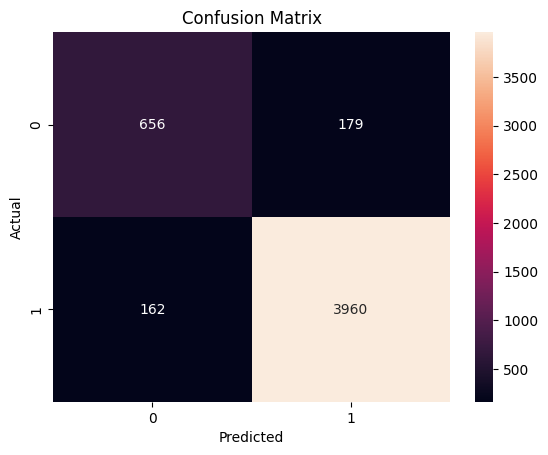

In [ ]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("/content/drive/MyDrive/FINAL MINI PROJECT/roberta_confusion_matrix.png")

In [ ]:
from transformers import RobertaForSequenceClassification, RobertaTokenizer
import torch

model_path = "/content/drive/MyDrive/FINAL MINI PROJECT/roberta_model"

model = RobertaForSequenceClassification.from_pretrained(model_path)
tokenizer = RobertaTokenizer.from_pretrained(model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
def roberta_predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)

    harmful_prob = probs[0][1].item()
    safe_prob = probs[0][0].item()

    prediction = torch.argmax(probs).item()

    print("\nInput:", text)
    print(f"Harmful: {harmful_prob:.3f} | Safe: {safe_prob:.3f}")

    if prediction == 1:
        print("Prediction: ⚠ Harmful")
    else:
        print("Prediction: ✅ Safe")

In [ ]:
roberta_predict("i hate your community")
roberta_predict("you")
roberta_predict("you look pretty")
roberta_predict("you are stupid")
roberta_predict("nice work bro")
roberta_predict("i will destroy you")


Input: i hate your community
Harmful: 0.989 | Safe: 0.011
Prediction: ⚠ Harmful

Input: you
Harmful: 0.138 | Safe: 0.862
Prediction: ✅ Safe

Input: you look pretty
Harmful: 0.138 | Safe: 0.862
Prediction: ✅ Safe

Input: you are stupid
Harmful: 0.989 | Safe: 0.011
Prediction: ⚠ Harmful

Input: nice work bro
Harmful: 0.989 | Safe: 0.011
Prediction: ⚠ Harmful

Input: i will destroy you
Harmful: 0.138 | Safe: 0.862
Prediction: ✅ Safe


In [ ]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0  # use GPU
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def llm_predict(text):
    labels = ["harmful", "safe"]

    result = classifier(text, labels)

    label = result['labels'][0]
    score = result['scores'][0]

    if label == "harmful":
        return f"⚠ Harmful ({score:.2f})"
    else:
        return f"✅ Safe ({score:.2f})"

In [ ]:
def final_predict_debug(text):
    print("\n==============================")
    print("Input:", text)

    # RoBERTa
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)

    roberta_conf = torch.max(probs).item()
    roberta_pred = torch.argmax(probs).item()

    print(f"RoBERTa → {'Harmful' if roberta_pred==1 else 'Safe'} ({roberta_conf:.2f})")

    # 🔥 NEW LOGIC
    llm_result = llm_predict(text)

    # If both agree → accept
    if (roberta_pred == 1 and "Harmful" in llm_result) or (roberta_pred == 0 and "Safe" in llm_result):
        print("FINAL → Agreement (Both models)")
        print("Result:", llm_result)

    # If disagree → trust LLM (more intelligent)
    else:
        print("FINAL → Conflict → Using LLM")
        print("Result:", llm_result)

In [ ]:
final_predict_debug("you")
final_predict_debug("you look pretty")
final_predict_debug("nice work bro")
final_predict_debug("i hate your community")
final_predict_debug("i will destroy you")
final_predict_debug("you are stupid")
final_predict_debug("i love your work")
final_predict_debug("go kill yourself")


Input: you
RoBERTa → Safe (0.86)
FINAL → Agreement (Both models)
Result: ✅ Safe (0.64)

Input: you look pretty
RoBERTa → Safe (0.86)
FINAL → Agreement (Both models)
Result: ✅ Safe (0.93)

Input: nice work bro
RoBERTa → Harmful (0.99)
FINAL → Conflict → Using LLM
Result: ✅ Safe (0.89)

Input: i hate your community
RoBERTa → Harmful (0.99)


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


FINAL → Agreement (Both models)
Result: ⚠ Harmful (0.98)

Input: i will destroy you
RoBERTa → Safe (0.86)
FINAL → Conflict → Using LLM
Result: ⚠ Harmful (0.99)

Input: you are stupid
RoBERTa → Harmful (0.99)
FINAL → Agreement (Both models)
Result: ⚠ Harmful (0.91)

Input: i love your work
RoBERTa → Safe (0.86)
FINAL → Agreement (Both models)
Result: ✅ Safe (0.89)

Input: go kill yourself
RoBERTa → Safe (0.86)
FINAL → Conflict → Using LLM
Result: ⚠ Harmful (0.98)
